In [239]:
%matplotlib inline

import random
import math
import time
import os
from os.path import join
import sys
import pandas as pd
pd.set_option('display.max_columns', 500)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy
import bz2

from nltk.tokenize import sent_tokenize

from nltk.tokenize import TweetTokenizer
from nltk.tokenize import RegexpTokenizer
tweet_tokenize = TweetTokenizer().tokenize
regex_tokenize = RegexpTokenizer(r'\w+').tokenize

import matplotlib.colors as mcolors
import pickle

from tqdm.notebook import tqdm_notebook

#import statsmodels as sm
import statsmodels.api as sm
import scipy.stats as st
from statsmodels.tools.tools import add_constant
from statsmodels.regression.linear_model import OLS
from sklearn import linear_model
from sklearn import preprocessing

emotion_columns = ["surprise", 'surprise_ekman', 'surprise_card', 'surprise_zs',
                   "love", "love_card", "love_zs",
                   "optimism", "optimism_card", "optimism_zs",
                   "excitement", "excitement_zs",
                   "pride", "pride_zs",
                   "relief", "relief_zs",
                   "fear", 'fear_ekman', 'fear_card', 'fear_zs',
                   "disappointment", 'disappointment_zs',
                   "guilt_zs", 
                   "anger", 'anger_ekman', 'anger_card', "anger_zs", 
                   "disgust", "disgust_ekman", "disgust_card", 'disgust_zs'
            ]

dimensions = emotion_columns
dimensions_redux = emotion_columns
dimensions_names = emotion_columns
dimensions_names_redux = emotion_columns
dims2name = {}

for dim in emotion_columns:
    if dim not in dims2name:
        dims2name[dim] = dim

def ci(x, confidence=0.95):
    avg = np.mean(x)
    low, high = st.t.interval(confidence, len(x)-1, loc=avg, scale=st.sem(x))
    return (avg, high-avg)
    
#dimension-dependent weights
def standardized_dimension_score(x,mu,std):
    zscore = (x-mu)/std
    if zscore >= 0:
        return 1/(1+zscore)
    else:
        zscore = -zscore
        return 2 - (1/(1+zscore))

In [240]:
# positive_emotions = ["love", "optimism", "excitement", "pride", "relief"]
# negative_emotions = ["fear", "anger", "disgust", "disappointment", "guilt"]
# ambiguous_emotions = ["surprise"]

In [241]:
positive_emotions = ["love", "love_card", "love_zs",
                   "optimism", "optimism_card", "optimism_zs",
                   "excitement", "excitement_zs",
                   "pride", "pride_zs",
                   "relief", "relief_zs"]
negative_emotions = ["fear", 'fear_ekman', 'fear_card', 'fear_zs',
                   "disappointment", 'disappointment_zs',
                   "guilt_zs", 
                   "anger", 'anger_ekman', 'anger_card', "anger_zs", 
                   "disgust", "disgust_ekman", "disgust_card", 'disgust_zs']
ambiguous_emotions = ["surprise", 'surprise_ekman', 'surprise_card', 'surprise_zs']

In [242]:
D = pd.read_csv("../data/paragraph_turns_ekman.csv")

ekman_emotions = ['joy', 'surprise', 'neutral', 'anger', 'sadness', 'fear', 'disgust']
dummies = pd.get_dummies(D['ekman'])
dummies = dummies.reindex(columns=ekman_emotions, fill_value=0)
dummies.columns = [f"{col}_ekman" for col in dummies.columns]
dummies = dummies.astype(int)
D = pd.concat([D, dummies], axis=1)
# columns_to_remove = [
#     'gratitude', 'excitement', 'joy', 'neutral', 'approval', 'admiration', 
#     'relief', 'caring', 'realization', 'pride', 'desire', 'annoyance', 
#     'amusement', 'confusion', 'sadness', 'curiosity', 'disapproval', 
#     'nervousness', 'disappointment', 'grief', 
#     'remorse', 'embarrassment','anger', 'disgust'
# ]
# D = D.drop(columns=columns_to_remove)

In [243]:
#ekman: joy, surprise, anger, sadness, fear, disgust
# goekman = pd.read_csv("../data/paragraph_turns_ekman.csv")
# goekman
# cardiffnlp: 'joy', 'optimism','anticipation', 'love', 'trust', 'surprise', 'sadness', 'disgust', 'fear', 'pessimism', 'anger'
cardiffnlp = pd.read_csv("../data/paragraph_turns_new_emotions.csv")
# llama
disappointment = pd.read_csv("../data/paragraph_turns_disappointment.csv")
excitement = pd.read_csv("../data/paragraph_turns_excitement.csv")
pride = pd.read_csv("../data/paragraph_turns_pride.csv")
guilt = pd.read_csv("../data/paragraph_turns_guilt.csv")
relief = pd.read_csv("../data/paragraph_turns_relief.csv")
# llama all
anger = pd.read_csv("../data/paragraph_turns_emotions/paragraph_turns_anger.csv")
disgust = pd.read_csv("../data/paragraph_turns_emotions/paragraph_turns_disgust.csv")
embarassment = pd.read_csv("../data/paragraph_turns_emotions/paragraph_turns_embarassment.csv")
empathy = pd.read_csv("../data/paragraph_turns_emotions/paragraph_turns_empathy.csv")
fear = pd.read_csv("../data/paragraph_turns_emotions/paragraph_turns_fear.csv")
frustration = pd.read_csv("../data/paragraph_turns_emotions/paragraph_turns_frustration.csv")
love = pd.read_csv("../data/paragraph_turns_emotions/paragraph_turns_love.csv")
optimism = pd.read_csv("../data/paragraph_turns_emotions/paragraph_turns_optimism.csv")
realization = pd.read_csv("../data/paragraph_turns_emotions/paragraph_turns_realization.csv")
sadness = pd.read_csv("../data/paragraph_turns_emotions/paragraph_turns_sadness.csv")
surprise = pd.read_csv("../data/paragraph_turns_emotions/paragraph_turns_surprise.csv")

In [244]:
D['surprise_card'] = cardiffnlp['surprise']
D['love_card'] = cardiffnlp['love']
D['optimism_card'] = cardiffnlp['optimism']
# excitment could be anticipation?
D['disgust_card'] = cardiffnlp['disgust']
D['fear_card'] = cardiffnlp['fear']
D['anger_card'] = cardiffnlp['anger']

D['surprise_zs'] = surprise['surprise']
D['love_zs'] = love['love']
D['optimism_zs'] = optimism['optimism']
D['disgust_zs'] = disgust['disgust']
D['disappointment_zs'] = disappointment['disappointment']
D['excitement_zs'] = excitement['excitement']
D['pride_zs'] = pride['pride']
D['guilt_zs'] = guilt['guilt']
D['relief_zs'] = relief['relief']
D['anger_zs'] = anger['anger']
D['fear_zs'] = fear['fear']

In [245]:
columns_to_move = ['problem_solution', 'call_to_action', 'intention', 'execution']
D = D[[col for col in D.columns if col not in columns_to_move] + columns_to_move]

In [246]:
D.columns

Index(['sentence', 'collectiveAction', 'racialJustice',
       'collectiveActionMulti', 'episode_id', 'sentence_length', 'speaker',
       'newSpeaker', 'mfcc1_sma3Mean', 'mfcc2_sma3Mean', 'mfcc3_sma3Mean',
       'mfcc4_sma3Mean', 'F0semitoneFrom27_5Hz_sma3nzMean',
       'F1frequency_sma3nzMean', 'startTime', 'endTime', 'duration',
       'turnCount', 'streak', 'streak_length', 'gratitude', 'excitement',
       'joy', 'neutral', 'approval', 'admiration', 'relief', 'caring',
       'optimism', 'realization', 'surprise', 'pride', 'desire', 'love',
       'annoyance', 'amusement', 'confusion', 'sadness', 'curiosity', 'fear',
       'disapproval', 'nervousness', 'disgust', 'disappointment', 'anger',
       'grief', 'remorse', 'embarrassment', 'ekman', 'joy_ekman',
       'surprise_ekman', 'neutral_ekman', 'anger_ekman', 'sadness_ekman',
       'fear_ekman', 'disgust_ekman', 'surprise_card', 'love_card',
       'optimism_card', 'disgust_card', 'fear_card', 'anger_card',
       'surprise_z

In [247]:
for column in emotion_columns:
    D[f'{column}_weighted'] = D[column].copy()

In [248]:
D['number_of_words'] = D['sentence'].apply(lambda x: len(str(x).split()))
D['log_number_of_words'] = D['number_of_words'].apply(lambda x: np.log(x) if x > 0 else 0)

THRESHOLD

In [249]:
threshold = 0.5
for column in emotion_columns:
    D[f'{column}'] = (D[column] >= threshold).astype(int)

In [250]:
df = D[['collectiveAction'] + ['problem_solution'] + ['call_to_action'] + ['intention'] + ['execution'] + emotion_columns + [f'{col}_weighted' for col in emotion_columns] + ['log_number_of_words']]

In [251]:
df.head(1)

,collectiveAction,problem_solution,call_to_action,intention,execution,surprise,surprise_ekman,surprise_card,surprise_zs,love,love_card,love_zs,optimism,optimism_card,optimism_zs,excitement,excitement_zs,pride,pride_zs,relief,relief_zs,fear,fear_ekman,fear_card,fear_zs,disappointment,disappointment_zs,guilt_zs,anger,anger_ekman,anger_card,anger_zs,disgust,disgust_ekman,disgust_card,disgust_zs,surprise_weighted,surprise_ekman_weighted,surprise_card_weighted,surprise_zs_weighted,love_weighted,love_card_weighted,love_zs_weighted,optimism_weighted,optimism_card_weighted,optimism_zs_weighted,excitement_weighted,excitement_zs_weighted,pride_weighted,pride_zs_weighted,relief_weighted,relief_zs_weighted,fear_weighted,fear_ekman_weighted,fear_card_weighted,fear_zs_weighted,disappointment_weighted,disappointment_zs_weighted,guilt_zs_weighted,anger_weighted,anger_ekman_weighted,anger_card_weighted,anger_zs_weighted,disgust_weighted,disgust_ekman_weighted,disgust_card_weighted,disgust_zs_weighted,log_number_of_words
0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.001327,0,0.092119,0,0.004947,0.830495,0,0.007183,0.964376,1,0.016931,0,0.002663,1,0.002415,0,0.000956,0,0.033691,0,0.002409,0,0,0.001449,0,0.048885,0,0.001214,0,0.078114,0,4.744932


delta = collective action

++++++++++++surprise
avg. delta : 0.0006726759047490919 count delta: 14866
avg. nodelta : 0.006633680508096189 count nodelta: 329229
OR = 0.10079824927361275
#dim-delta=10, #nodim-delta=14856, #dim-nodelta=2184, #nodim-nodelta=327045
++++++++++++surprise_ekman
avg. delta : 0.2864926678326382 count delta: 14866
avg. nodelta : 0.154828402115245 count nodelta: 329229
OR = 2.1918424490195623
#dim-delta=4259, #nodim-delta=10607, #dim-nodelta=50974, #nodim-nodelta=278255
++++++++++++surprise_card
avg. delta : 0.05166150948473026 count delta: 14866
avg. nodelta : 0.018218322201264167 count nodelta: 329229
OR = 2.9356904375038524
#dim-delta=768, #nodim-delta=14098, #dim-nodelta=5998, #nodim-nodelta=323231
++++++++++++surprise_zs
avg. delta : 0.15713709134938786 count delta: 14866
avg. nodelta : 0.14058907325903855 count nodelta: 329229
OR = 1.1396488862283387
#dim-delta=2336, #nodim-delta=12530, #dim-nodelta=46286, #nodim-nodelta=282943
++++++++++++love
avg. delta : 0.0026907036189963676 count

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_34162/3302467764.py:68: RuntimeWarning: overflow encountered in exp
  ci_OR_upper = np.exp(log_OR + ci_log_OR)


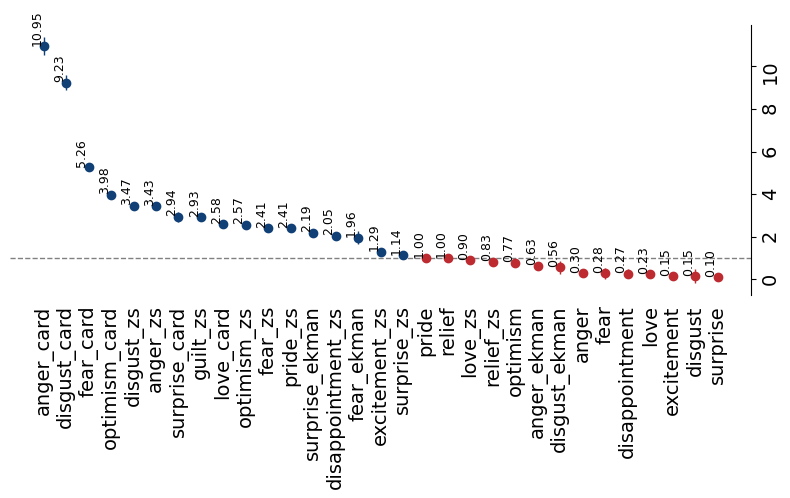

In [252]:
import numpy as np
import matplotlib.pyplot as plt

all_dims = dimensions_names_redux 

def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

df_no_delta = df[df['collectiveAction'] == 0].dropna()
df_delta = df[df['collectiveAction'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio.pdf')
plt.show()

In [253]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio.csv', index=False)
print(f"Results saved to '../plots/odds_ratio.csv'")

Results saved to '../plots/odds_ratio.csv'


In [254]:
results_df.columns

Index(['emotion', 'odds_ratio', 'lower_ci', 'upper_ci'], dtype='object')

In [255]:
# Map each emotion to a category
def get_category(emotion):
    if emotion in positive_emotions:
        return "positive"
    elif emotion in negative_emotions:
        return "negative"
    elif emotion in ambiguous_emotions:
        return "ambiguous"
    else:
        return "unknown"

# Add a category column
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_simple.csv', index=False)
print(f"Results saved!")

Results saved!


++++++++++++surprise
avg. delta : 0.0006993006993006993 count delta: 10010
avg. nodelta : 0.00654623823278507 count nodelta: 334085
OR = 0.10619978158358617
#dim-delta=7, #nodim-delta=10003, #dim-nodelta=2187, #nodim-nodelta=331898
++++++++++++surprise_ekman
avg. delta : 0.31478521478521476 count delta: 10010
avg. nodelta : 0.15589445799721627 count nodelta: 334085
OR = 2.4874460809523744
#dim-delta=3150, #nodim-delta=6860, #dim-nodelta=52082, #nodim-nodelta=282003
++++++++++++surprise_card
avg. delta : 0.05904095904095904 count delta: 10010
avg. nodelta : 0.01848332011314486 count nodelta: 334085
OR = 3.331964635182655
#dim-delta=591, #nodim-delta=9419, #dim-nodelta=6175, #nodim-nodelta=327910
++++++++++++surprise_zs
avg. delta : 0.16913086913086914 count delta: 10010
avg. nodelta : 0.14047023960968016 count nodelta: 334085
OR = 1.2455663064446822
#dim-delta=1693, #nodim-delta=8317, #dim-nodelta=46929, #nodim-nodelta=287156
++++++++++++love
avg. delta : 0.0016983016983016983 count del

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_34162/753407568.py:68: RuntimeWarning: overflow encountered in exp
  ci_OR_upper = np.exp(log_OR + ci_log_OR)


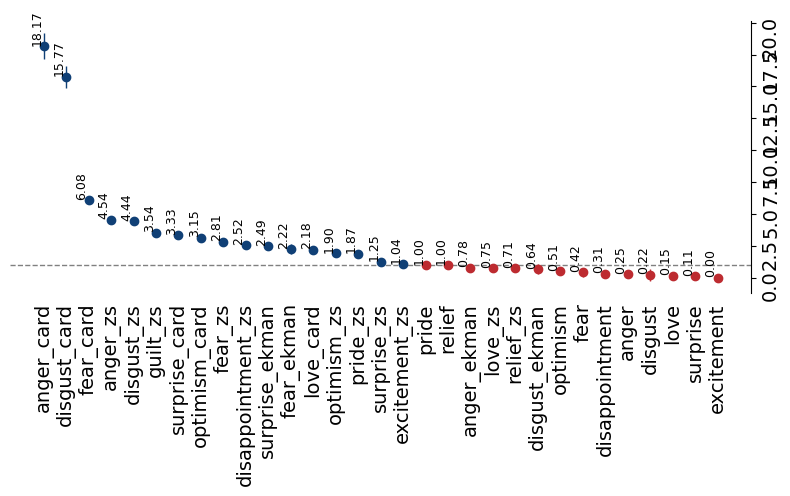

In [256]:
import numpy as np
import matplotlib.pyplot as plt

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['problem_solution'] == 0].dropna()
df_delta = df[df['problem_solution'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_problem_solution.pdf')
plt.show()

In [257]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_problem_solution.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_problem_solution.csv'")

Results saved to '../plots/odds_ratio_problem_solution.csv'


In [258]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_problem_solution_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [259]:
odds_problem_solution = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

odds_problem_solution.head()

,Emotion,Odds Ratio,Lower CI,Upper CI
0,surprise,0.106200,-0.010692,0.223092
1,surprise_ekman,2.487446,2.377613,2.597280
2,surprise_card,3.331965,3.029667,3.634262
3,surprise_zs,1.245566,1.177557,1.313575
4,love,0.149454,0.058137,0.240771


++++++++++++surprise
avg. delta : 0.0 count delta: 1653
avg. nodelta : 0.0064069243842752935 count nodelta: 342442
OR = 0.00015508128543680044
#dim-delta=0, #nodim-delta=1653, #dim-nodelta=2194, #nodim-nodelta=340248
++++++++++++surprise_ekman
avg. delta : 0.22807017543859648 count delta: 1653
avg. nodelta : 0.16019063082215382 count nodelta: 342442
OR = 1.5489388746735258
#dim-delta=377, #nodim-delta=1276, #dim-nodelta=54856, #nodim-nodelta=287586
++++++++++++surprise_card
avg. delta : 0.06654567453115548 count delta: 1653
avg. nodelta : 0.019436868141174273 count nodelta: 342442
OR = 3.5964665954185158
#dim-delta=110, #nodim-delta=1543, #dim-nodelta=6656, #nodim-nodelta=335786
++++++++++++surprise_zs
avg. delta : 0.13793103448275862 count delta: 1653
avg. nodelta : 0.14132028197475777 count nodelta: 342442
OR = 0.9721800223168161
#dim-delta=228, #nodim-delta=1425, #dim-nodelta=48394, #nodim-nodelta=294048
++++++++++++love
avg. delta : 0.0030248033877797943 count delta: 1653
avg. node

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_34162/855220156.py:68: RuntimeWarning: overflow encountered in exp
  ci_OR_upper = np.exp(log_OR + ci_log_OR)


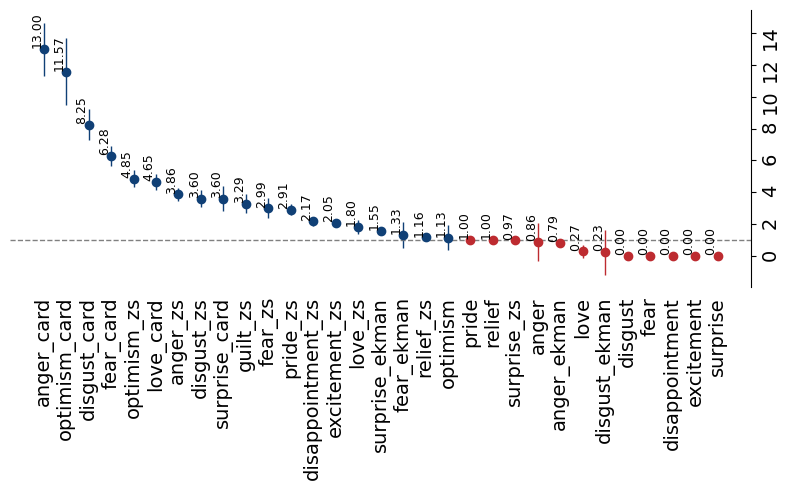

In [260]:
import numpy as np
import matplotlib.pyplot as plt

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['call_to_action'] == 0].dropna()
df_delta = df[df['call_to_action'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_call_to_action.pdf')
plt.show()

In [261]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_call_to_action.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_call_to_action.csv'")

Results saved to '../plots/odds_ratio_call_to_action.csv'


In [262]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_call_to_action_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [263]:
odds_call_to_action = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

++++++++++++surprise
avg. delta : 0.001088929219600726 count delta: 2755
avg. nodelta : 0.006418819944922951 count nodelta: 341340
OR = 0.1687411437381253
#dim-delta=3, #nodim-delta=2752, #dim-nodelta=2191, #nodim-nodelta=339149
++++++++++++surprise_ekman
avg. delta : 0.32704174228675137 count delta: 2755
avg. nodelta : 0.15917267240874203 count nodelta: 341340
OR = 2.5671625670167533
#dim-delta=901, #nodim-delta=1854, #dim-nodelta=54332, #nodim-nodelta=287008
++++++++++++surprise_card
avg. delta : 0.06352087114337568 count delta: 2755
avg. nodelta : 0.019309193179820706 count nodelta: 341340
OR = 3.444976941777547
#dim-delta=175, #nodim-delta=2580, #dim-nodelta=6591, #nodim-nodelta=334749
++++++++++++surprise_zs
avg. delta : 0.14301270417422868 count delta: 2755
avg. nodelta : 0.14129020917560203 count nodelta: 341340
OR = 1.0142256302891632
#dim-delta=394, #nodim-delta=2361, #dim-nodelta=48228, #nodim-nodelta=293112
++++++++++++love
avg. delta : 0.005081669691470054 count delta: 2755

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_34162/1804142765.py:68: RuntimeWarning: overflow encountered in exp
  ci_OR_upper = np.exp(log_OR + ci_log_OR)


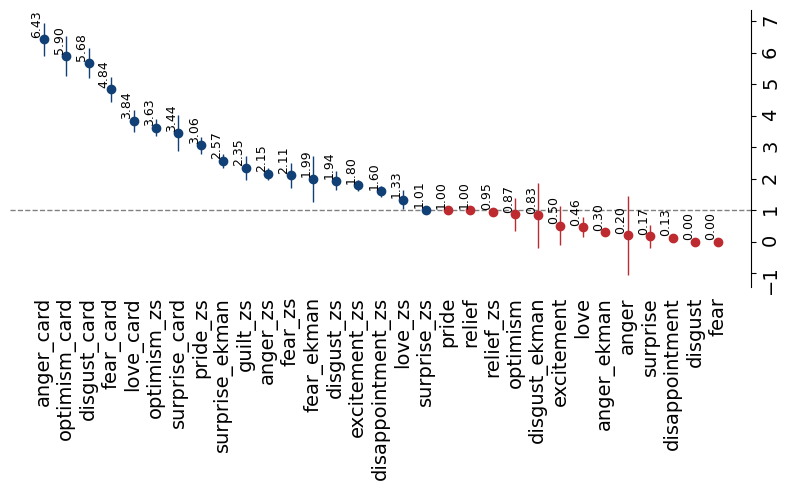

In [264]:
import numpy as np
import matplotlib.pyplot as plt

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['intention'] == 0].dropna()
df_delta = df[df['intention'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_intention.pdf')
plt.show()

In [265]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_intention.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_intention.csv'")

Results saved to '../plots/odds_ratio_intention.csv'


In [266]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_intention_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [267]:
odds_intention = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

++++++++++++surprise
avg. delta : 0.0 count delta: 2861
avg. nodelta : 0.006429605490660368 count nodelta: 341234
OR = 0.00015453069236113901
#dim-delta=0, #nodim-delta=2861, #dim-nodelta=2194, #nodim-nodelta=339040
++++++++++++surprise_ekman
avg. delta : 0.23488290807409998 count delta: 2861
avg. nodelta : 0.1598932111102645 count nodelta: 341234
OR = 1.612976281659225
#dim-delta=672, #nodim-delta=2189, #dim-nodelta=54560, #nodim-nodelta=286674
++++++++++++surprise_card
avg. delta : 0.06081789584061517 count delta: 2861
avg. nodelta : 0.01931812187531137 count nodelta: 341234
OR = 3.2873415600463938
#dim-delta=174, #nodim-delta=2687, #dim-nodelta=6592, #nodim-nodelta=334642
++++++++++++surprise_zs
avg. delta : 0.1118490038448095 count delta: 2861
avg. nodelta : 0.141550959165851 count nodelta: 341234
OR = 0.7637426019499413
#dim-delta=320, #nodim-delta=2541, #dim-nodelta=48302, #nodim-nodelta=292932
++++++++++++love
avg. delta : 0.0017476406850751485 count delta: 2861
avg. nodelta : 0

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_34162/960445758.py:68: RuntimeWarning: overflow encountered in exp
  ci_OR_upper = np.exp(log_OR + ci_log_OR)


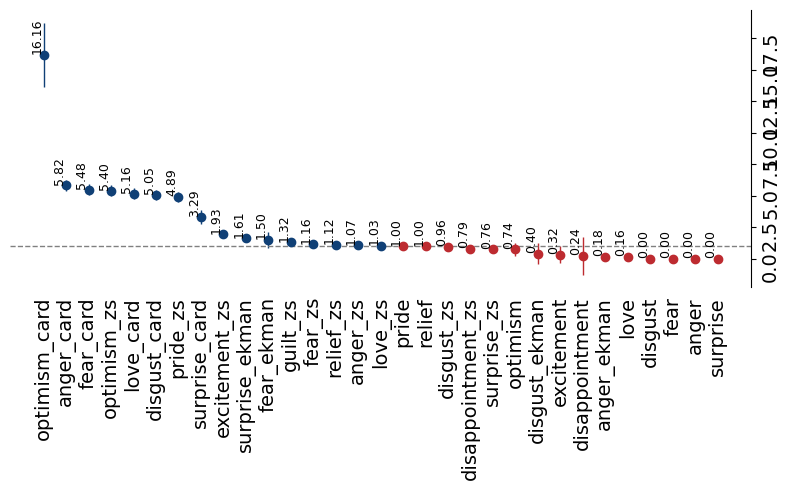

In [268]:
import numpy as np
import matplotlib.pyplot as plt

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['execution'] == 0].dropna()
df_delta = df[df['execution'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_execution.pdf')
plt.show()

In [269]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_execution.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_execution.csv'")

Results saved to '../plots/odds_ratio_execution.csv'


In [270]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_execution_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [271]:
odds_execution = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

Matrix of significant odds ratios

In [272]:
odds_dfs = {
    'Problem-Solution': odds_problem_solution,
    'Call-to-Action': odds_call_to_action,
    'Intention': odds_intention,
    'Execution': odds_execution
}
odds_matrix = pd.DataFrame({'Emotion': odds_problem_solution['Emotion']})

for level, df in odds_dfs.items():
    df_filtered = df[(df['Lower CI'] > 1) | (df['Upper CI'] < 1)]  # Keep only significant odds ratios
    df_filtered = df_filtered[['Emotion', 'Odds Ratio']].rename(columns={'Odds Ratio': level})
    odds_matrix = odds_matrix.merge(df_filtered, on='Emotion', how='left')

odds_matrix
odds_matrix.set_index('Emotion', inplace=True)
odds_matrix

,Problem-Solution,Call-to-Action,Intention,Execution
Emotion,,,,
surprise,0.106200,NaN,0.168741,NaN
surprise_ekman,2.487446,1.548939,2.567163,1.612976
surprise_card,3.331965,3.596467,3.444977,3.287342
surprise_zs,1.245566,NaN,NaN,0.763743
love,0.149454,0.272407,0.458203,0.156626
love_card,2.182642,4.648189,3.840569,5.161841
love_zs,0.749383,1.803922,1.327730,NaN
optimism,0.510951,NaN,NaN,NaN
optimism_card,3.146760,11.568590,5.902614,16.164356


In [273]:
min_value = odds_matrix.min().min()
max_value = odds_matrix.max().max()

print(f"Smallest value: {min_value}")
print(f"Largest value: {max_value}")

Smallest value: 0.10619978158358617
Largest value: 18.170362320774277


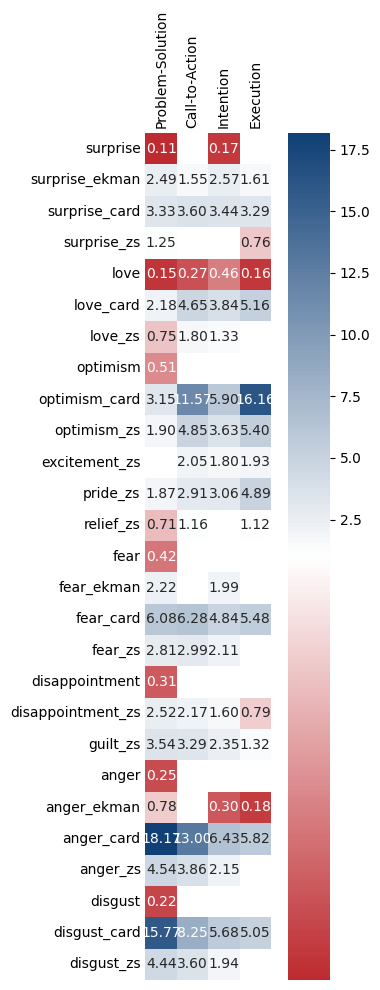

In [274]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Filter out rows where all values are NaN
odds_matrix_significant = odds_matrix.dropna(how='all')

# Check if 'Emotion' is the index, if not, set it as the index
if 'Emotion' in odds_matrix_significant.columns:
    odds_matrix_significant = odds_matrix_significant.set_index('Emotion', drop=True)

# Ensure all data is numeric
odds_matrix_significant = odds_matrix_significant.apply(pd.to_numeric, errors='coerce')

# Define a custom diverging colormap with 1.00 centered at white
colors = ["#BD2B30", "white", "#104076"]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# Use a symmetric scale to center at 1.0
divnorm = mcolors.TwoSlopeNorm(vcenter=1.0)

# Create the heatmap
plt.figure(figsize=(4, 10))
ax = sns.heatmap(
    odds_matrix_significant, 
    annot=True, 
    cmap=custom_cmap, 
    norm=divnorm,  # Ensure white is at 1.00
    fmt=".2f", 
    square=True,
    linewidths=0,  # Remove lines between rows and columns
    #cbar_kws={'label': 'Odds Ratio'},
    xticklabels=True,  # Show x-axis labels (levels of participation)
    yticklabels=True  # Show y-axis labels (emotions)
)

# # Set ticks and labels on colormap from 0.25 to 4 with steps of 0.25
# cbar = ax.collections[0].colorbar
# cbar.set_ticks(np.arange(0.25, 4.25, 0.25))
# cbar.set_ticklabels(np.arange(0.25, 4.25, 0.25).round(2))  # Set tick labels

# Move xticks to top
ax.xaxis.set_ticks_position('top')

# Remove tick marks but keep the labels
ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# Ensure x and y axis labels are visible and aligned correctly
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # Make sure x labels are not rotated
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated



# Remove title and x/y labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

# Show the plot
plt.tight_layout()
plt.savefig('../plots/heatmap.pdf', orientation='landscape')

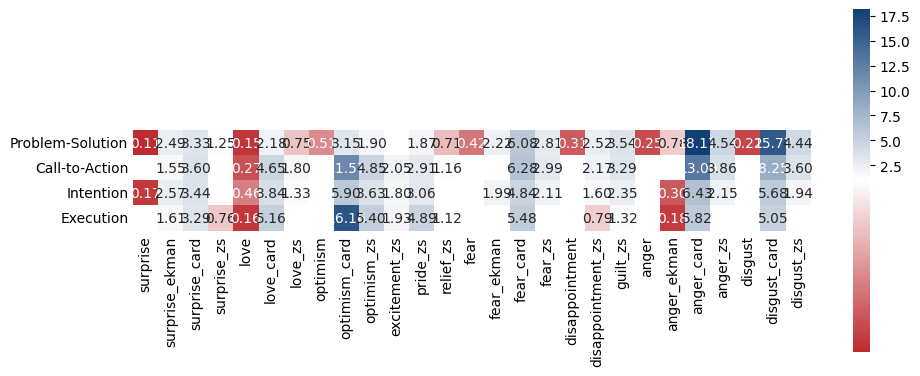

In [275]:
# Transpose the data to switch x and y axes
odds_matrix_significant_transposed = odds_matrix_significant.transpose()

colors = ["#BD2B30", "white", "#104076"]  # Swap blue and red

# Create the heatmap with transposed data
plt.figure(figsize=(10, 4))  # Adjust figure size if needed
ax = sns.heatmap(
    odds_matrix_significant_transposed, 
    annot=True, 
    cmap=custom_cmap, 
    norm=divnorm,  # Ensure white is at 1.00
    fmt=".2f", 
    square=True,
    linewidths=0,  # Remove lines between rows and columns
    xticklabels=True,  # Show x-axis labels (levels of participation)
    yticklabels=True  # Show y-axis labels (emotions)
)

# Move yticks to the left (default)
ax.yaxis.set_ticks_position('left')

# Remove tick marks but keep the labels
ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# Ensure x and y axis labels are visible and aligned correctly
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # Make sure x labels are not rotated
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# Remove title and x/y labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

# Show the plot
plt.tight_layout()
plt.savefig('../plots/heatmap.pdf', orientation='landscape')


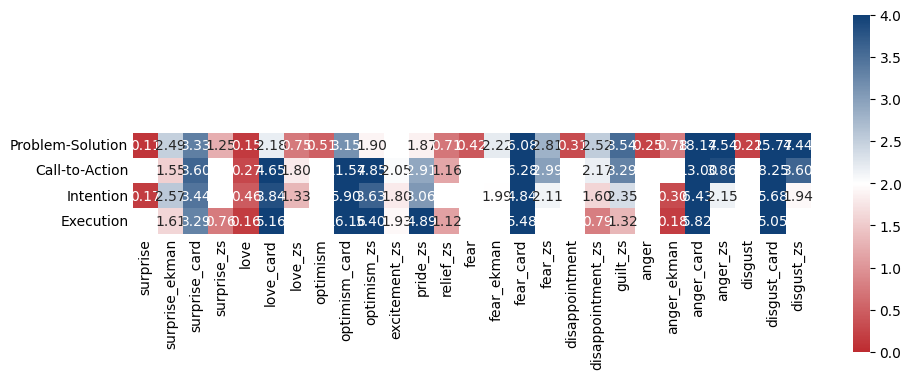

In [276]:
# Define a custom diverging colormap with 1.00 centered at white, but switch blue and red
colors = ["#BD2B30", "white", "#104076"]  # Swap blue and red
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# Use a symmetric scale to center at 2.0, while keeping 1.0 as white
divnorm = mcolors.TwoSlopeNorm(vmin=0, vcenter=2.0, vmax=4)

# Create the heatmap with transposed data and updated colormap
plt.figure(figsize=(10, 4))  # Adjust figure size if needed
ax = sns.heatmap(
    odds_matrix_significant_transposed, 
    annot=True, 
    cmap=custom_cmap, 
    norm=divnorm,  # Set center of colormap to 2.0
    fmt=".2f", 
    square=True,
    linewidths=0,  # Remove lines between rows and columns
    xticklabels=True,  # Show x-axis labels (levels of participation)
    yticklabels=True  # Show y-axis labels (emotions)
)

# Move yticks to the left (default)
ax.yaxis.set_ticks_position('left')

# Remove tick marks but keep the labels
ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# Ensure x and y axis labels are visible and aligned correctly
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # Make sure x labels are not rotated
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# Remove title and x/y labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

# Show the plot
plt.tight_layout()
plt.savefig('../plots/heatmap.pdf', orientation='landscape')

In [277]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors

# # Filter out rows where all values are NaN
# odds_matrix_significant = odds_matrix.dropna(how='all')

# # Check if 'Emotion' is the index, if not, set it as the index
# if 'Emotion' in odds_matrix_significant.columns:
#     odds_matrix_significant = odds_matrix_significant.set_index('Emotion', drop=True)

# # Ensure all data is numeric
# odds_matrix_significant = odds_matrix_significant.apply(pd.to_numeric, errors='coerce')

# # Define a custom colormap
# colors = ["#BD2B30", "white", "#104076"]  # Red for -3, white for 1, blue for 5
# custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# # Define the custom normalization with the vmin and vmax parameters
# norm = mcolors.Normalize(vmin=0, vmax=5)

# # Create the heatmap
# plt.figure(figsize=(10, 8))
# ax = sns.heatmap(
#     odds_matrix_significant, 
#     annot=True, 
#     cmap=custom_cmap,  # Apply the custom colormap
#     norm=norm,  # Use the custom normalization
#     fmt=".2f", 
#     linewidths=0,  # Remove lines between rows and columns
#     cbar_kws={'label': 'Odds Ratio'},
#     xticklabels=True,  # Show x-axis labels (levels of participation)
#     yticklabels=True  # Show y-axis labels (emotions)
# )

# # Move xticks to top
# ax.xaxis.set_ticks_position('top')

# # Remove tick marks but keep the labels
# ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
# ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# # Ensure x and y axis labels are visible and aligned correctly
# ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # Make sure x labels are not rotated
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# # Remove title and x/y labels
# ax.set_title('')
# ax.set_xlabel('')
# ax.set_ylabel('')

# # Show the plot
# plt.tight_layout()
# plt.show()

In [278]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# import numpy as np

# # Filter out rows where all values are NaN
# odds_matrix_significant = odds_matrix.dropna(how='all')

# # Check if 'Emotion' is the index, if not, set it as the index
# if 'Emotion' in odds_matrix_significant.columns:
#     odds_matrix_significant = odds_matrix_significant.set_index('Emotion', drop=True)

# # Ensure all data is numeric
# odds_matrix_significant = odds_matrix_significant.apply(pd.to_numeric, errors='coerce')

# # Define a custom colormap
# colors = ["#BD2B30", "white", "#104076"]  # Red for the smallest value, white for 1, blue for the largest value
# custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# # Get the smallest and largest values in the matrix
# vmin = odds_matrix_significant.min().min()  # smallest value in the dataframe
# vmax = odds_matrix_significant.max().max()  # largest value in the dataframe

# # Define custom boundaries and normalization
# boundaries = [vmin, 1, vmax]  # Define custom bins for color mapping
# norm = mcolors.BoundaryNorm(boundaries, custom_cmap.N)

# # Create the heatmap
# plt.figure(figsize=(10, 8))
# ax = sns.heatmap(
#     odds_matrix_significant, 
#     annot=True, 
#     cmap=custom_cmap,  # Apply the custom colormap
#     norm=norm,  # Use the custom normalization with boundaries
#     fmt=".2f", 
#     linewidths=0,  # Remove lines between rows and columns
#     cbar_kws={'label': 'Odds Ratio'},
#     xticklabels=True,  # Show x-axis labels (levels of participation)
#     yticklabels=True  # Show y-axis labels (emotions)
# )

# # Move xticks to top
# ax.xaxis.set_ticks_position('top')

# # Remove tick marks but keep the labels
# ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
# ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# # Ensure x and y axis labels are visible and aligned correctly
# ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # Make sure x labels are not rotated
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# # Remove title and x/y labels
# ax.set_title('')
# ax.set_xlabel('')
# ax.set_ylabel('')

# # Show the plot
# plt.tight_layout()
# plt.show()
